# MLP_model
#### Modèle MLP multi-cibles pour la prediction des conso_énergétiques
Après l'établissement d'un modèle de référence basé sur LightGBM, un réseau de neurones de type Multi-Layer Perceptron (MLP) est entraîné sur le même découpage stratifié des données.
L'objectif est de comparer les performances d'un modèle de Deep Learning avec un modèle basé sur les arbres de décision, en utilisant les mêmes jeux d'entraînement, validation et test.


In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

ROOT = Path().resolve().parent.parent
DATA = ROOT / "data" / "processed"

X = pd.read_parquet(DATA / "X.parquet")
Y = pd.read_parquet(DATA / "y.parquet")

idx_train = np.load(DATA / "idx_train.npy")
idx_test  = np.load(DATA / "idx_test.npy")

X_train = X.iloc[idx_train].reset_index(drop=True)
X_test  = X.iloc[idx_test].reset_index(drop=True)

Y_train = Y.iloc[idx_train].reset_index(drop=True)
Y_test  = Y.iloc[idx_test].reset_index(drop=True)
X_total = len(X_train) + len(X_test)
Y_total = len(Y_train) + len(Y_test)

print(f"Train : {X_train.shape} ({len(X_train)/X_total:.1%})")
print(f"Test  : {X_test.shape} ({len(X_test)/X_total:.1%})")

print(f"Train : {Y_train.shape} ({len(Y_train)/Y_total:.1%})")
print(f"Test  : {Y_test.shape} ({len(Y_test)/Y_total:.1%})")


Train : (439976, 110) (80.0%)
Test  : (109995, 110) (20.0%)
Train : (439976, 5) (80.0%)
Test  : (109995, 5) (20.0%)


## Creation de la validation-set

In [3]:

X_train_final, X_val, Y_train_final, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42
)
X_total = len(X_train_final) + len(X_val) + len(X_test)
Y_total = len(Y_train_final) + len(Y_val) + len(Y_test)

print(f"Train : {X_train_final.shape} ({len(X_train_final)/X_total:.1%})")
print(f"Val   : {X_val.shape} ({len(X_val)/X_total:.1%})")
print(f"Test  : {X_test.shape} ({len(X_test)/X_total:.1%})")

print(f"Train : {Y_train_final.shape} ({len(Y_train_final)/Y_total:.1%})")
print(f"Val   : {Y_val.shape} ({len(Y_val)/Y_total:.1%})")
print(f"Test  : {Y_test.shape} ({len(Y_test)/Y_total:.1%})")




Train : (351980, 110) (64.0%)
Val   : (87996, 110) (16.0%)
Test  : (109995, 110) (20.0%)
Train : (351980, 5) (64.0%)
Val   : (87996, 5) (16.0%)
Test  : (109995, 5) (20.0%)


## La normalisation

In [4]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_final)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

scaler_Y = StandardScaler()

Y_train_scaled = scaler_Y.fit_transform(Y_train_final)
Y_val_scaled   = scaler_Y.transform(Y_val)
Y_test_scaled  = scaler_Y.transform(Y_test)

X_total = len(X_train_scaled) + len(X_val_scaled) + len(X_test_scaled)
Y_total = len(Y_train_scaled) + len(Y_val_scaled) + len(Y_test_scaled)

print(f"Train : {X_train_final.shape} ({len(X_train_final)/X_total:.1%})")
print(f"Val   : {X_val.shape} ({len(X_val)/X_total:.1%})")
print(f"Test  : {X_test.shape} ({len(X_test)/X_total:.1%})")

print(f"Train : {Y_train_final.shape} ({len(Y_train_final)/Y_total:.1%})")
print(f"Val   : {Y_val.shape} ({len(Y_val)/Y_total:.1%})")
print(f"Test  : {Y_test.shape} ({len(Y_test)/Y_total:.1%})")




Train : (351980, 110) (64.0%)
Val   : (87996, 110) (16.0%)
Test  : (109995, 110) (20.0%)
Train : (351980, 5) (64.0%)
Val   : (87996, 5) (16.0%)
Test  : (109995, 5) (20.0%)


## Définition De dimensions

In [5]:
n_features = X_train_scaled.shape[1]
n_targets  = Y_train_scaled.shape[1]

print("Features :", n_features)
print("Targets  :", n_targets)


Features : 110
Targets  : 5


## Construction de notere modèle MLP et Compilation 

In [6]:
model = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=(n_features,)),
    layers.Dropout(0.2),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(128, activation="relu"),

    layers.Dense(n_targets)  # sortie multi-target
])

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)


C:\Users\yzouarhi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,701 (866.02 KB)

 Trainable params: 221,701 (866.02 KB)

 Non-trainable params: 0 (0.00 B)

## petite verification

## 

In [7]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))
print("GPU is available" if tf.config.list_physical_devices('GPU') else "GPU is not available")

[]
GPU is not available


## Entrainement

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    Y_train_scaled,
    validation_data=(X_val_scaled, Y_val_scaled),
    epochs=200,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.3524 - mae: 0.2711 - val_loss: 0.2930 - val_mae: 0.2357
Epoch 2/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 0.2988 - mae: 0.2309 - val_loss: 0.2737 - val_mae: 0.2118
Epoch 3/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 0.2835 - mae: 0.2202 - val_loss: 0.2734 - val_mae: 0.2157
Epoch 4/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 0.2726 - mae: 0.2151 - val_loss: 0.2754 - val_mae: 0.2138
Epoch 5/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2660 - mae: 0.2122 - val_loss: 0.2698 - val_mae: 0.2099
Epoch 6/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2576 - mae: 0.2092 - val_loss: 0.2748 - val_mae: 0.2126
Epoch 7/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2497 - mae: 0.2068 - val_loss: 0.2686 - val_mae: 0.2141
Epoch 8/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2424 - mae: 0.2047 - val_loss: 0.2695 - val_mae: 0.2105
Epoch 9/200
1375/1375 ━

## visualisation des courbes d'apprentissage

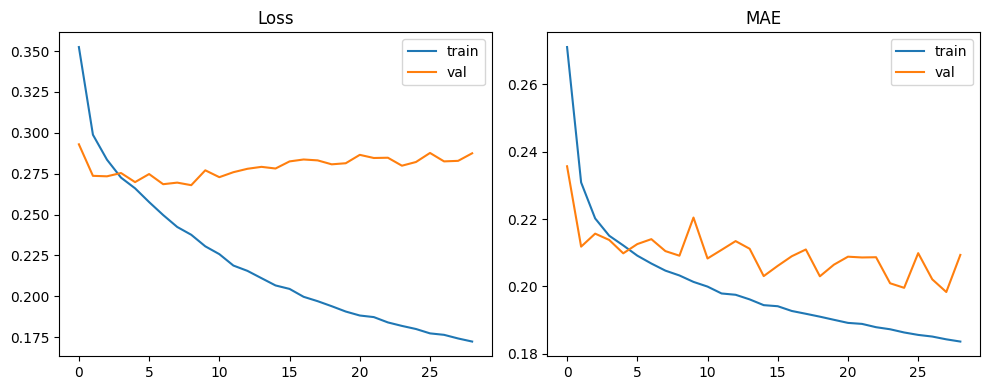

In [9]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.title("MAE")
plt.legend()

plt.tight_layout()
plt.show()


In [10]:
Y_pred_scaled = model.predict(X_test_scaled)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
Y_true = Y_test.values

3438/3438 ━━━━━━━━━━━━━━━━━━━━ 2s 455us/step


In [ ]:

Y_train_pred = model.predict(X_train_scaled)
Y_val_pred   = model.predict(X_val_scaled)
Y_test_pred  = model.predict(X_test_scaled)
results = {}

for i, target in enumerate(Y.columns):

    train_rmse = np.sqrt(mean_squared_error(Y_train_scaled[:, i], Y_train_pred[:, i]))
    train_mae  = mean_absolute_error(Y_train_scaled[:, i], Y_train_pred[:, i])
    train_r2   = r2_score(Y_train_scaled[:, i], Y_train_pred[:, i])

    val_rmse = np.sqrt(mean_squared_error(Y_val_scaled[:, i], Y_val_pred[:, i]))
    val_mae  = mean_absolute_error(Y_val_scaled[:, i], Y_val_pred[:, i])
    val_r2   = r2_score(Y_val_scaled[:, i], Y_val_pred[:, i])

    test_rmse = np.sqrt(mean_squared_error(Y_test_scaled[:, i], Y_test_pred[:, i]))
    test_mae  = mean_absolute_error(Y_test_scaled[:, i], Y_test_pred[:, i])
    test_r2   = r2_score(Y_test_scaled[:, i], Y_test_pred[:, i])

    results[target] = {
        "Train_RMSE": train_rmse,
        "Train_MAE": train_mae,
        "Train_R2": train_r2,
        "Val_RMSE": val_rmse,
        "Val_MAE": val_mae,
        "Val_R2": val_r2,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Test_R2": test_r2,
    }

df_results = pd.DataFrame(results).T
df_results["Overfit_Gap"] = df_results["Train_R2"] - df_results["Test_R2"]
df_results = df_results.sort_values("Test_R2", ascending=False)

display(df_results.round(4))
#############################===============ATTENTION le overfit ==================##################

11000/11000 ━━━━━━━━━━━━━━━━━━━━ 5s 471us/step
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 1s 460us/step
3438/3438 ━━━━━━━━━━━━━━━━━━━━ 2s 471us/step


,Train_RMSE,Train_MAE,Train_R2,Val_RMSE,Val_MAE,Val_R2,Test_RMSE,Test_MAE,Test_R2,Overfit_Gap
out.emissions.total.lrmer_mid_case_25..co2e_kg,0.3266,0.2110,0.8934,0.3511,0.2185,0.8768,0.3518,0.2188,0.8744,0.0189
out.natural_gas.total.energy_consumption..kwh,0.3673,0.2052,0.8651,0.3896,0.2117,0.8490,0.3921,0.2127,0.8447,0.0204
out.electricity.total.energy_consumption..kwh,0.4146,0.2604,0.8281,0.4474,0.2690,0.8042,0.4439,0.2689,0.8011,0.0270
out.fuel_oil.total.energy_consumption..kwh,0.5130,0.1425,0.7368,0.6012,0.1558,0.6391,0.6052,0.1580,0.6220,0.1148
out.propane.total.energy_consumption..kwh,0.5958,0.1722,0.6450,0.7093,0.1908,0.4843,0.7399,0.1954,0.4536,0.1915


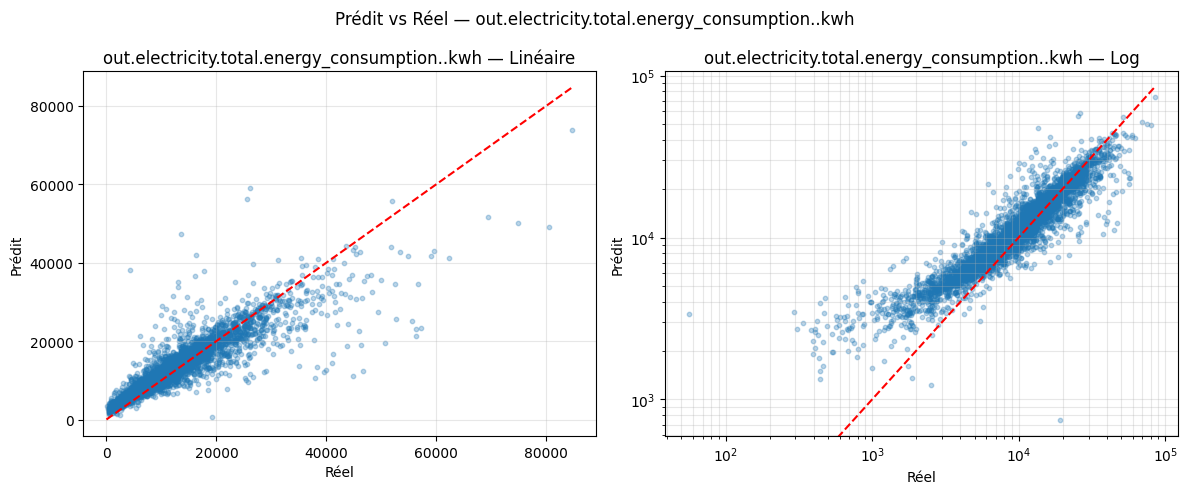

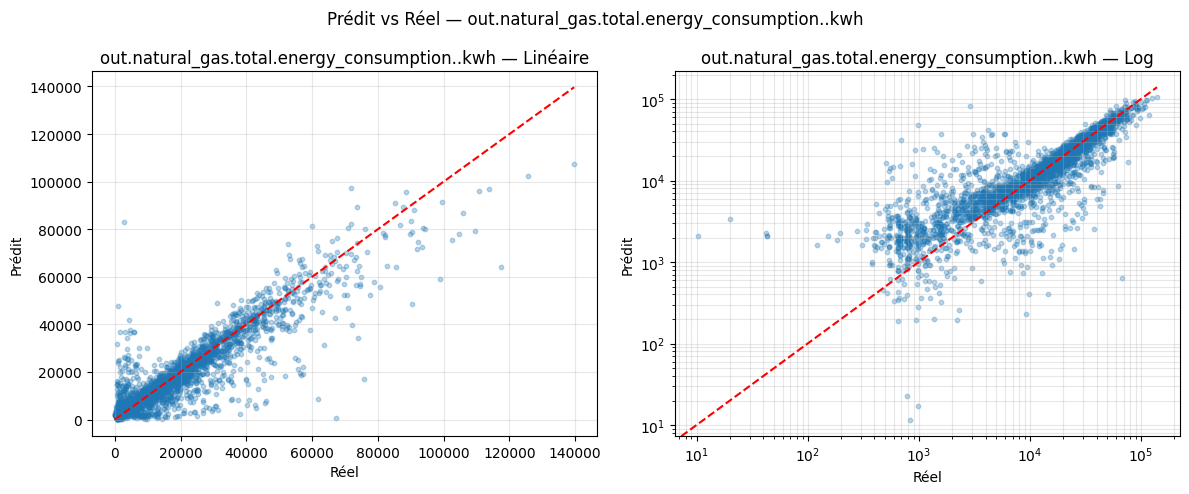

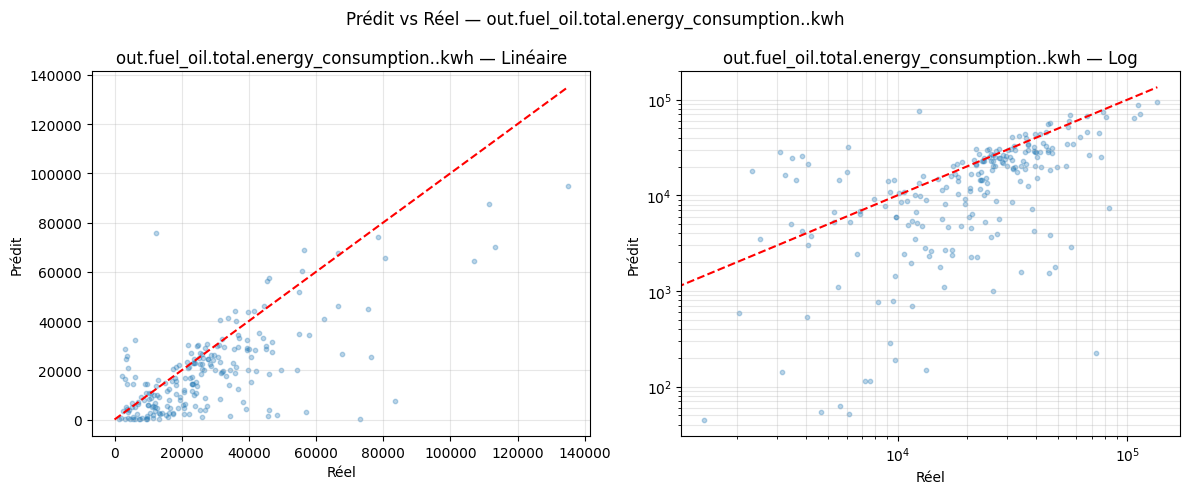

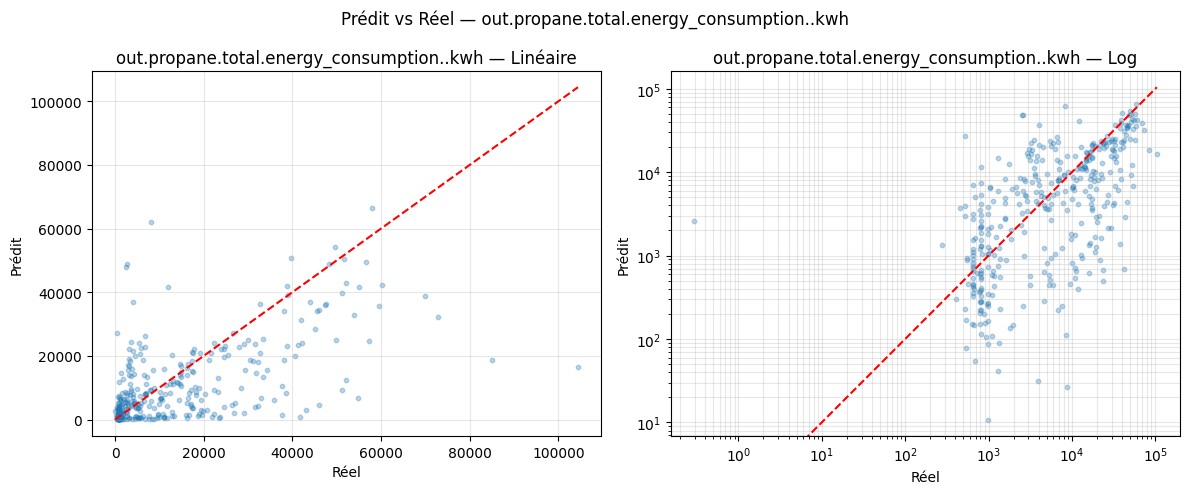

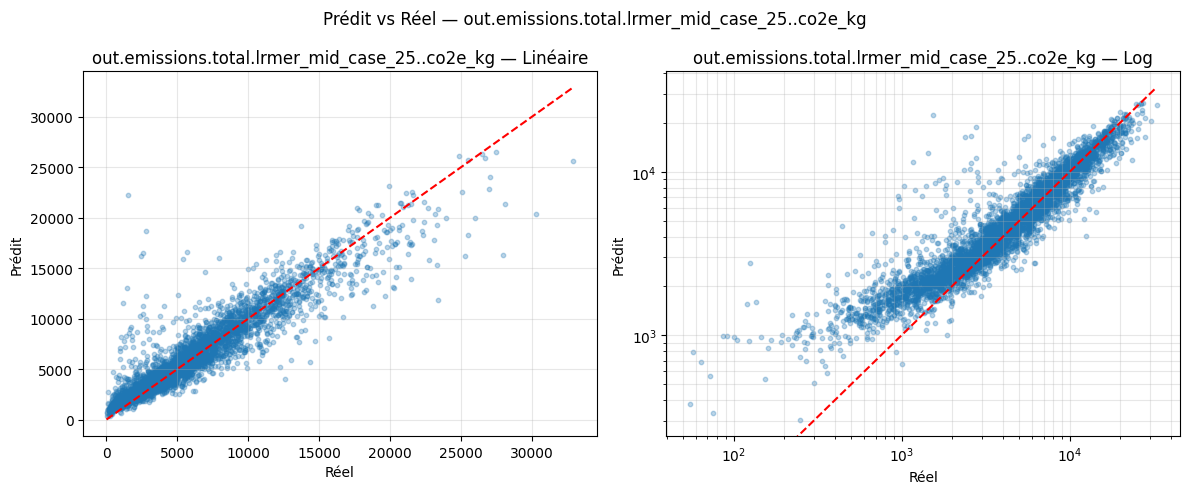

In [16]:
rng = np.random.default_rng(42)

for i, col in enumerate(Y.columns):

    y_true = Y_true[:, i]
    y_pred = Y_pred[:, i]

    # échantillon
    n = min(5000, len(y_true))
    idx = rng.choice(len(y_true), n, replace=False)

    y_true_s = y_true[idx]
    y_pred_s = y_pred[idx]

    # éviter log(0)
    mask = (y_true_s > 0) & (y_pred_s > 0)
    y_true_s = y_true_s[mask]
    y_pred_s = y_pred_s[mask]

    lim = max(y_true_s.max(), y_pred_s.max())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # linéraire
    axes[0].scatter(y_true_s, y_pred_s, alpha=0.3, s=10)
    axes[0].plot([0, lim], [0, lim], "r--")
    axes[0].set_title(f"{col} — Linéaire")
    axes[0].set_xlabel("Réel")
    axes[0].set_ylabel("Prédit")
    axes[0].grid(alpha=0.3)

  # log
    axes[1].scatter(y_true_s, y_pred_s, alpha=0.3, s=10)
    axes[1].plot([0, lim], [0, lim], "r--")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_title(f"{col} — Log")
    axes[1].set_xlabel("Réel")
    axes[1].set_ylabel("Prédit")
    axes[1].grid(alpha=0.3, which="both")

    plt.suptitle(f"Prédit vs Réel — {col}")
    plt.tight_layout()
    plt.show()
